In [143]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from gensim.models import Word2Vec
from sklearn.svm import LinearSVC

In [144]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake['label'] = 0
true['label'] = 1

## Naive Bayes

In [145]:
df = pd.concat([fake, true], ignore_index=True)

print('Fake articles:', len(fake))
print('True articles:', len(true))
df.head()

Fake articles: 23481
True articles: 21417


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [146]:
df.shape

(44898, 5)

In [147]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [148]:
df['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

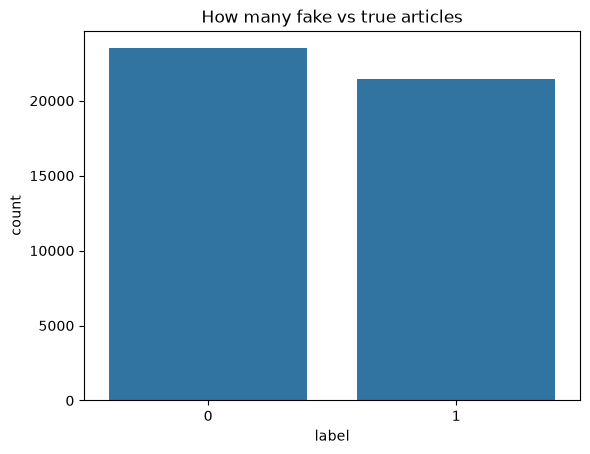

In [149]:
sns.countplot(x='label', data=df)
plt.title('How many fake vs true articles')
plt.show()

## Clean the text

In [150]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [151]:
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

df['clean_text'] = df['content'].apply(clean_text)

df[['content', 'clean_text', 'label']].head()

,content,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends out embarrassing new year s...,0
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes an internet joke ...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump is so obsessed he even has obama s name ...,0
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis just called out donald trump duri...,0


## Split into training data and test data

In [152]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 35918
Testing rows: 8980


In [153]:
results = []

## Count Vectorizer

Count Vectorizer just counts how many times each word appears in each article.

In [154]:
count_vectorizer = CountVectorizer(max_features=10000, stop_words='english')
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print('Shape of training data:', X_train_count.shape)

Shape of training data: (35918, 10000)


In [155]:
model_count = MultinomialNB()
model_count.fit(X_train_count, y_train)

predictions_count = model_count.predict(X_test_count)

accuracy_count = accuracy_score(y_test, predictions_count)

print('Accuracy:', accuracy_count)

results.append({'Vectorizer': 'Count', 'Accuracy': accuracy_count})

Accuracy: 0.9455456570155902


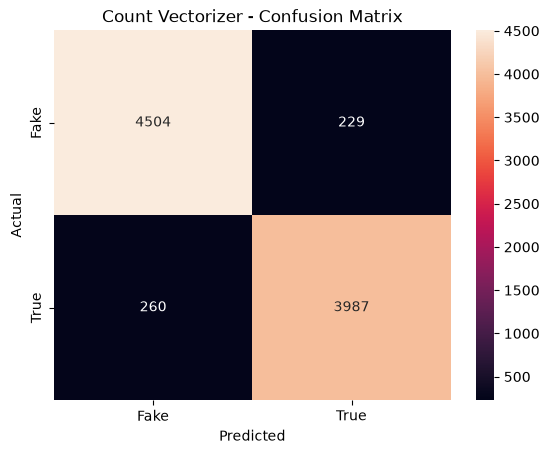

In [156]:
cm = confusion_matrix(y_test, predictions_count)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Count Vectorizer - Confusion Matrix')
plt.show()


## TF-IDF Vectorizer

TF-IDF also counts words, but gives less weight to common words and more weight to rare,
more meaningful words.

In [157]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print('Shape of training data:', X_train_tfidf.shape)

Shape of training data: (35918, 10000)


In [158]:
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

predictions_tfidf = model_tfidf.predict(X_test_tfidf)

accuracy_tfidf = accuracy_score(y_test, predictions_tfidf)

print('Accuracy:', accuracy_tfidf)

results.append({'Vectorizer': 'TF-IDF', 'Accuracy': accuracy_tfidf})

Accuracy: 0.9309576837416481


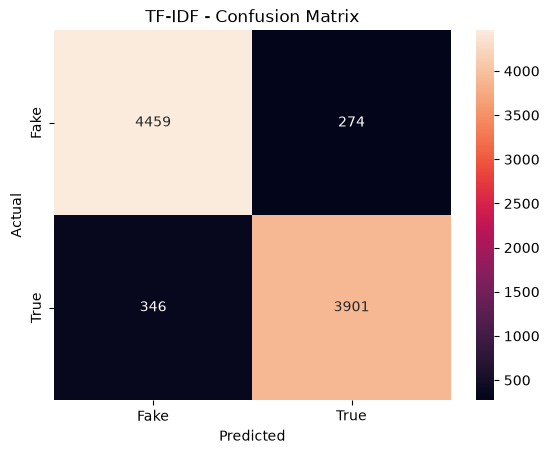

In [159]:
cm = confusion_matrix(y_test, predictions_tfidf)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('TF-IDF - Confusion Matrix')
plt.show()

## Word2Vec

Word2Vec is different: it learns a vector for each word based on the words around it, so
similar words end up with similar vectors. To represent a whole article, we average the
vectors of all its words.

We use `GaussianNB` here instead of `MultinomialNB`, because Word2Vec vectors can be
negative numbers, and `MultinomialNB` only works with positive counts.

In [160]:
train_words = X_train.str.split()
test_words = X_test.str.split()

w2v_model = Word2Vec(sentences=train_words.tolist(), vector_size=100, window=5, min_count=2, seed=42)

print('Vocabulary size:', len(w2v_model.wv))

Vocabulary size: 68730


In [161]:
def get_average_vector(words, model, size=100):
    word_vectors = []
    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])

    if len(word_vectors) == 0:
        return np.zeros(size)

    return np.mean(word_vectors, axis=0)

In [162]:
X_train_w2v = np.array([get_average_vector(words, w2v_model) for words in train_words])
X_test_w2v = np.array([get_average_vector(words, w2v_model) for words in test_words])

print('Shape of training data:', X_train_w2v.shape)

Shape of training data: (35918, 100)


In [163]:
model_w2v = GaussianNB()
model_w2v.fit(X_train_w2v, y_train)

predictions_w2v = model_w2v.predict(X_test_w2v)

accuracy_w2v = accuracy_score(y_test, predictions_w2v)

print('Accuracy:', accuracy_w2v)

results.append({'Vectorizer': 'Word2Vec', 'Accuracy': accuracy_w2v})

Accuracy: 0.9089086859688196


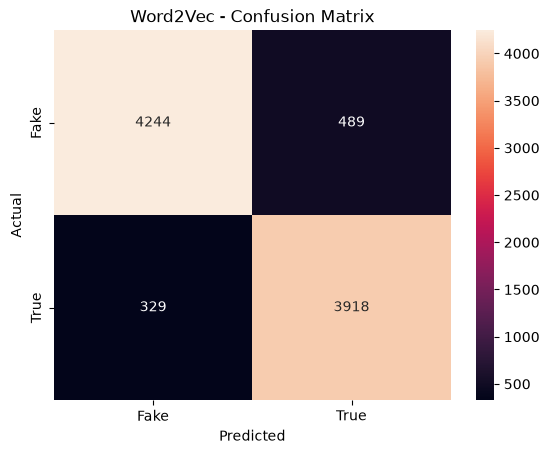

In [164]:
cm = confusion_matrix(y_test, predictions_w2v)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Word2Vec - Confusion Matrix')
plt.show()

## Compare

In [165]:
results_df = pd.DataFrame(results)
results_df

,Vectorizer,Accuracy
0,Count,0.945546
1,TF-IDF,0.930958
2,Word2Vec,0.908909


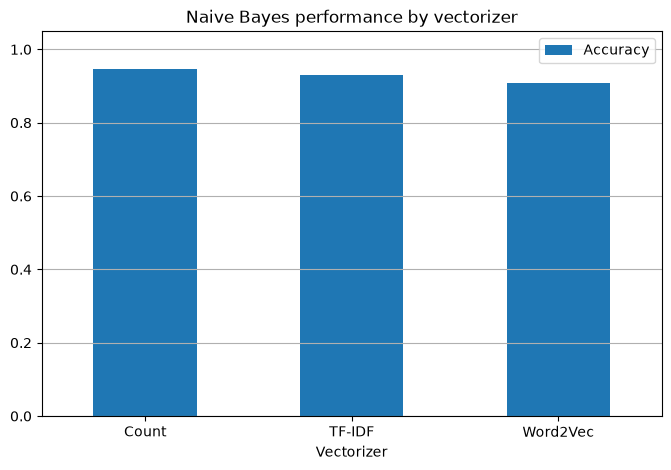

In [166]:
results_df.plot(x='Vectorizer', y=['Accuracy'], kind='bar', rot=0, figsize=(8, 5))
plt.ylim(0, 1.05)
plt.title('Naive Bayes performance by vectorizer')
plt.grid(axis='y')
plt.show()

## Test

In [167]:
ext_df = pd.read_csv('fake_data.csv')

ext_df['content'] = ext_df['Headline'].fillna('') + ' ' + ext_df['Body'].fillna('')
ext_df['clean_text'] = ext_df['content'].apply(clean_text)

X_ext = ext_df['clean_text']
y_ext = ext_df['Label']

print('External test set size:', len(X_ext))

External test set size: 4009


In [168]:
ext_results = []

X_ext_count = count_vectorizer.transform(X_ext)
pred = model_count.predict(X_ext_count)
ext_results.append({'Vectorizer': 'Count',
                     'Accuracy': accuracy_score(y_ext, pred)})

# TF-IDF Vectorizer
X_ext_tfidf = tfidf_vectorizer.transform(X_ext)
pred = model_tfidf.predict(X_ext_tfidf)
ext_results.append({'Vectorizer': 'TF-IDF',
                     'Accuracy': accuracy_score(y_ext, pred)})

# Word2Vec Vectorizer
ext_words = X_ext.str.split()
X_ext_w2v = np.array([get_average_vector(words, w2v_model) for words in ext_words])
pred = model_w2v.predict(X_ext_w2v)
ext_results.append({'Vectorizer': 'Word2Vec',
                     'Accuracy': accuracy_score(y_ext, pred)})

ext_results_df = pd.DataFrame(ext_results)
ext_results_df

,Vectorizer,Accuracy
0,Count,0.712647
1,TF-IDF,0.708157
2,Word2Vec,0.708157


## SVM

# 2. Load Dataset

In [169]:
data = pd.read_csv("fake_data.csv")

print("Dataset Shape:", data.shape)

Dataset Shape: (4009, 4)


# 3. Define Labels


In [170]:
label_names = {
    0: "Fake News",
    1: "True News"
}

# 4. Label Distribution

In [171]:
label_counts = data["Label"].value_counts().sort_index()

print("\nLabel Distribution:")

for label, count in label_counts.items():
    print(f"{label} = {label_names[label]}: {count}")


print("\nTotal Fake News:",
      label_counts.get(0, 0))

print("Total True News:",
      label_counts.get(1, 0))


Label Distribution:
0 = Fake News: 2137
1 = True News: 1872

Total Fake News: 2137
Total True News: 1872


# 5. Check Missing Values


In [172]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
URLs         0
Headline     0
Body        21
Label        0
dtype: int64


# 6. Handle Missing Values


In [173]:
data["Headline"] = data["Headline"].fillna("")
data["Body"] = data["Body"].fillna("")

# 7. Combine Headline and Body


In [174]:
data["Text"] = (
    data["Headline"] + " " + data["Body"]
)

# 8. Text Cleaning


In [175]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Keep English letters and spaces
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


data["Clean_Text"] = data["Text"].apply(clean_text)

# 9. Prepare Features and Target


In [176]:
X = data["Clean_Text"]
y = data["Label"]

# 10. Train / Test Split


In [177]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 3207
Testing Samples: 802


# 11. SVM + Count Vectorizer


In [178]:
count_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

X_train_count = count_vectorizer.fit_transform(
    X_train
)

X_test_count = count_vectorizer.transform(
    X_test
)


svm_count = LinearSVC(
    C=1.0,
    max_iter=5000
)

svm_count.fit(
    X_train_count,
    y_train
)


pred_count = svm_count.predict(
    X_test_count
)


count_accuracy = accuracy_score(
    y_test,
    pred_count
)

count_f1 = f1_score(
    y_test,
    pred_count
)


print("\nSVM + Count Vectorizer")
print("----------------------")
print("Accuracy:", round(count_accuracy, 4))
print("F1 Score:", round(count_f1, 4))


SVM + Count Vectorizer
----------------------
Accuracy: 0.9813
F1 Score: 0.9801


## 12. SVM + TF-IDF

In [179]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)


svm_tfidf = LinearSVC(
    C=1.0,
    max_iter=5000
)

svm_tfidf.fit(
    X_train_tfidf,
    y_train
)


pred_tfidf = svm_tfidf.predict(
    X_test_tfidf
)


tfidf_accuracy = accuracy_score(
    y_test,
    pred_tfidf
)

tfidf_f1 = f1_score(
    y_test,
    pred_tfidf
)


print("\nSVM + TF-IDF")
print("------------")
print("Accuracy:", round(tfidf_accuracy, 4))
print("F1 Score:", round(tfidf_f1, 4))


SVM + TF-IDF
------------
Accuracy: 0.99
F1 Score: 0.9893


## 13. Initial SVM Comparison

In [180]:
results_df = pd.DataFrame({

    "Model": [
        "SVM + Count",
        "SVM + TF-IDF"
    ],

    "Accuracy": [
        count_accuracy,
        tfidf_accuracy
    ],

    "F1 Score": [
        count_f1,
        tfidf_f1
    ]
})


print("\nInitial SVM Comparison:")

display(results_df)


Initial SVM Comparison:


,Model,Accuracy,F1 Score
0,SVM + Count,0.981297,0.980132
1,SVM + TF-IDF,0.990025,0.989333


# 14. Create Validation Set


In [181]:
X_train_main, X_validation, y_train_main, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)


print("\nMain Training Samples:", len(X_train_main))
print("Validation Samples:", len(X_validation))


Main Training Samples: 2565
Validation Samples: 642


# 15. TF-IDF for Hyperparameter Tuning

In [182]:
tuning_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True
)


X_train_main_tfidf = tuning_vectorizer.fit_transform(
    X_train_main
)

X_validation_tfidf = tuning_vectorizer.transform(
    X_validation
)

# 16. Hyperparameter Tuning

In [183]:
C_values = [0.1, 1, 10]

tuning_results = []


for C in C_values:

    model = LinearSVC(
        C=C,
        max_iter=5000
    )

    model.fit(
        X_train_main_tfidf,
        y_train_main
    )

    validation_predictions = model.predict(
        X_validation_tfidf
    )

    validation_f1 = f1_score(
        y_validation,
        validation_predictions
    )

    tuning_results.append({

        "C": C,

        "Validation F1": validation_f1
    })


tuning_df = pd.DataFrame(
    tuning_results
)


print("\nSVM Hyperparameter Tuning:")

display(tuning_df)


SVM Hyperparameter Tuning:


,C,Validation F1
0,0.1,0.965404
1,1.0,0.978369
2,10.0,0.981758


# 17. Select Best C

In [184]:
best_C = tuning_df.loc[
    tuning_df["Validation F1"].idxmax(),
    "C"
]

print("Best C:", best_C)

Best C: 10.0


# 18. Train Final Tuned SVM

In [185]:
final_tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True
)


X_train_final_tfidf = final_tfidf_vectorizer.fit_transform(
    X_train
)

X_test_final_tfidf = final_tfidf_vectorizer.transform(
    X_test
)


final_svm = LinearSVC(
    C=best_C,
    max_iter=5000
)


final_svm.fit(
    X_train_final_tfidf,
    y_train
)


final_predictions = final_svm.predict(
    X_test_final_tfidf
)

# 19. Final Evaluation

In [186]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)


print("\nFINAL TUNED SVM")
print("================")
print("Best C:", best_C)
print("Accuracy:", round(final_accuracy, 4))
print("F1 Score:", round(final_f1, 4))


FINAL TUNED SVM
Best C: 10.0
Accuracy: 0.9913
F1 Score: 0.9907


# 20. Classification Report

In [187]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Fake News",
            "True News"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99       428
   True News       0.99      0.99      0.99       374

    accuracy                           0.99       802
   macro avg       0.99      0.99      0.99       802
weighted avg       0.99      0.99      0.99       802



# 21. Confusion Matrix

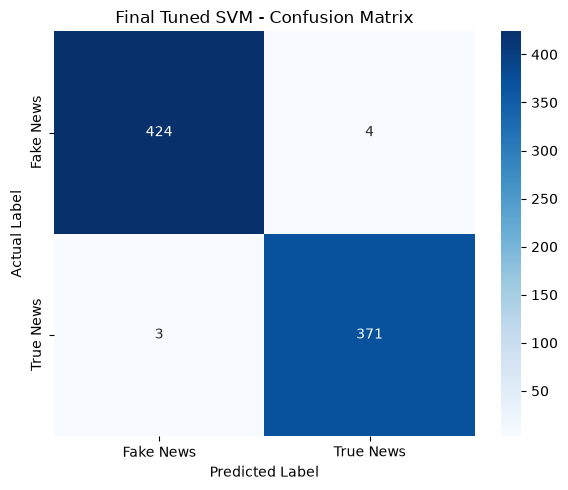

In [188]:
cm = confusion_matrix(
    y_test,
    final_predictions
)


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Fake News",
        "True News"
    ],
    yticklabels=[
        "Fake News",
        "True News"
    ]
)


plt.title(
    "Final Tuned SVM - Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()

plt.show()

# 22. Final SVM Comparison

In [189]:
final_results = results_df.copy()


final_results.loc[len(final_results)] = [

    "Tuned SVM + TF-IDF",

    final_accuracy,

    final_f1
]


final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
)


print("\nFinal SVM Comparison:")

display(final_results)


Final SVM Comparison:


,Model,Accuracy,F1 Score
2,Tuned SVM + TF-IDF,0.991272,0.990654
1,SVM + TF-IDF,0.990025,0.989333
0,SVM + Count,0.981297,0.980132


# 23. Accuracy Comparison

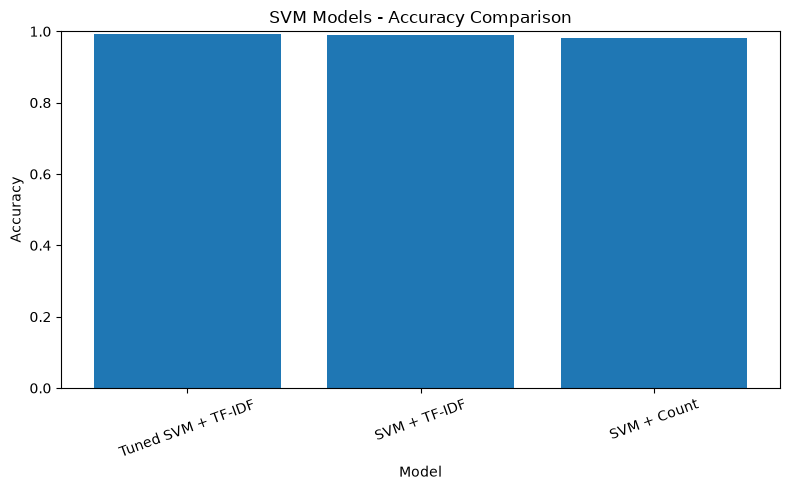

In [190]:
plt.figure(
    figsize=(8, 5)
)


plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)


plt.title(
    "SVM Models - Accuracy Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

# 24. F1 Score Comparison

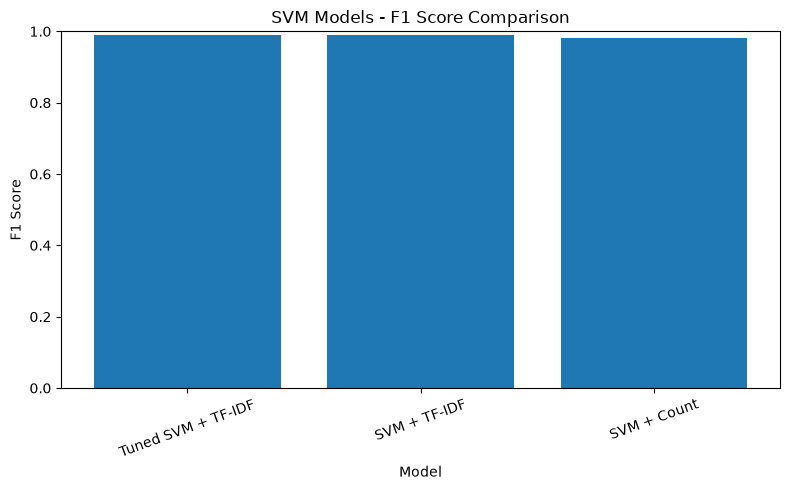

In [191]:
plt.figure(
    figsize=(8, 5)
)


plt.bar(
    final_results["Model"],
    final_results["F1 Score"]
)


plt.title(
    "SVM Models - F1 Score Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "F1 Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

# 25. New News Prediction

In [192]:
new_headline = (
    "Government announces a new economic plan"
)


new_body = """
The government announced a new economic plan today
that aims to create thousands of new jobs and increase
investment in several important sectors.
"""


new_text = clean_text(
    new_headline + " " + new_body
)


new_text_vectorized = final_tfidf_vectorizer.transform(
    [new_text]
)


prediction = final_svm.predict(
    new_text_vectorized
)[0]


if prediction == 0:

    prediction_result = "FAKE NEWS"

else:

    prediction_result = "TRUE NEWS"


print("\nNEW ARTICLE PREDICTION")
print("======================")
print("Predicted Label:", prediction)
print("Prediction:", prediction_result)


NEW ARTICLE PREDICTION
Predicted Label: 0
Prediction: FAKE NEWS


# Random Forest

In [ ]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [194]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [195]:
df = pd.concat([fake, true], axis=0).reset_index(drop=True)
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [196]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0


In [197]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv = CountVectorizer(max_features=5000)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

In [198]:
print(X_train_cv)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6326514 stored elements and shape (35918, 5000)>
  Coords	Values
  (0, 4652)	1
  (0, 2279)	6
  (0, 4562)	3
  (0, 4499)	10
  (0, 288)	2
  (0, 1189)	2
  (0, 3606)	3
  (0, 3032)	1
  (0, 153)	4
  (0, 1857)	3
  (0, 333)	1
  (0, 2689)	3
  (0, 678)	2
  (0, 3107)	3
  (0, 629)	4
  (0, 3891)	4
  (0, 4260)	1
  (0, 439)	2
  (0, 3365)	3
  (0, 1612)	1
  (0, 1635)	1
  (0, 4872)	1
  (0, 2470)	3
  (0, 4735)	3
  (0, 4427)	1
  :	:
  (35917, 1865)	1
  (35917, 792)	1
  (35917, 1321)	1
  (35917, 2659)	1
  (35917, 1412)	1
  (35917, 4216)	1
  (35917, 3158)	1
  (35917, 4015)	1
  (35917, 2390)	1
  (35917, 2862)	1
  (35917, 144)	2
  (35917, 939)	3
  (35917, 1843)	1
  (35917, 2059)	2
  (35917, 4966)	1
  (35917, 3554)	1
  (35917, 789)	1
  (35917, 186)	3
  (35917, 1027)	1
  (35917, 4072)	2
  (35917, 4559)	3
  (35917, 4855)	10
  (35917, 2231)	1
  (35917, 669)	1
  (35917, 2814)	6


In [199]:
print(X_test_cv)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1584112 stored elements and shape (8980, 5000)>
  Coords	Values
  (0, 119)	3
  (0, 159)	2
  (0, 171)	1
  (0, 175)	1
  (0, 178)	1
  (0, 179)	1
  (0, 183)	3
  (0, 201)	1
  (0, 202)	3
  (0, 204)	1
  (0, 226)	1
  (0, 235)	1
  (0, 248)	1
  (0, 276)	1
  (0, 286)	2
  (0, 298)	1
  (0, 300)	1
  (0, 307)	3
  (0, 313)	12
  (0, 334)	1
  (0, 343)	1
  (0, 347)	1
  (0, 372)	1
  (0, 378)	1
  (0, 385)	3
  :	:
  (8979, 4720)	1
  (8979, 4723)	1
  (8979, 4737)	1
  (8979, 4776)	1
  (8979, 4806)	1
  (8979, 4811)	1
  (8979, 4812)	2
  (8979, 4814)	2
  (8979, 4816)	1
  (8979, 4845)	5
  (8979, 4860)	5
  (8979, 4886)	1
  (8979, 4890)	1
  (8979, 4892)	1
  (8979, 4896)	2
  (8979, 4900)	4
  (8979, 4907)	1
  (8979, 4914)	1
  (8979, 4931)	2
  (8979, 4961)	4
  (8979, 4971)	1
  (8979, 4977)	2
  (8979, 4978)	2
  (8979, 4984)	5
  (8979, 4987)	1


In [200]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_cv.fit(X_train_cv, y_train)

y_pred_cv = rf_cv.predict(X_test_cv)

acc_cv = accuracy_score(y_test, y_pred_cv)
f1_cv = f1_score(y_test, y_pred_cv)

print("Accuracy : ", acc_cv)
print("F1-Score : ", f1_cv)

Accuracy :  0.9973273942093541
F1-Score :  0.9971870604781997
